<a href="https://colab.research.google.com/github/njakusi0-rgb/CIFAKE-image-detection-model-/blob/main/Fraud_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Step 1: Install required packages
!pip install kagglehub pandas numpy scikit-learn matplotlib seaborn xgboost imbalanced-learn -q

In [ ]:

# Step 2: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:

# Step 3: Download the dataset using kagglehub
import kagglehub

# Download latest version of credit card fraud dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print(path)
print(os.listdir(path))

file_path=os.path.join(path, "creditcard.csv")
data=pd.read_csv(file_path)
data.head(10)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
/kaggle/input/creditcardfraud
['creditcard.csv']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:

# Step 4: Load the dataset
import os

# List files in the downloaded directory
print("creditcard.csv:")
for file in os.listdir(path):
    print(f"  - {file}")

# Load the CSV file
df = pd.read_csv(os.path.join(path, 'creditcard.csv'))
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
display(df.head())

creditcard.csv:
  - creditcard.csv

Dataset shape: (284807, 31)

First few rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:

# Step 5: Basic dataset information
print("=== DATASET INFORMATION ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nBasic statistics:")
display(df.describe())

=== DATASET INFORMATION ===
Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10  

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


=== CLASS DISTRIBUTION ===
Non-Fraud (Class 0): 284315 (99.83%)
Fraud (Class 1): 492 (0.17%)


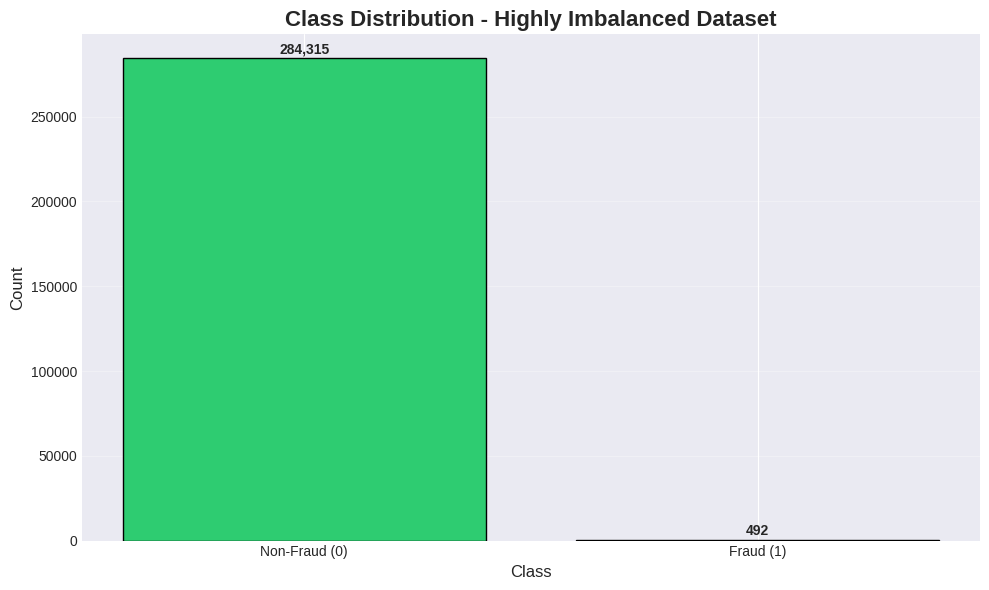

In [ ]:

# Step 6: Check class distribution (fraud vs non-fraud)
print("=== CLASS DISTRIBUTION ===")
class_counts = df['Class'].value_counts()
class_percentage = df['Class'].value_counts(normalize=True) * 100

print(f"Non-Fraud (Class 0): {class_counts[0]} ({class_percentage[0]:.2f}%)")
print(f"Fraud (Class 1): {class_counts[1]} ({class_percentage[1]:.2f}%)")

# Visualize class distribution
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(['Non-Fraud (0)', 'Fraud (1)'], class_counts, color=colors, edgecolor='black')
plt.title('Class Distribution - Highly Imbalanced Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

=== TRANSACTION AMOUNT ANALYSIS ===


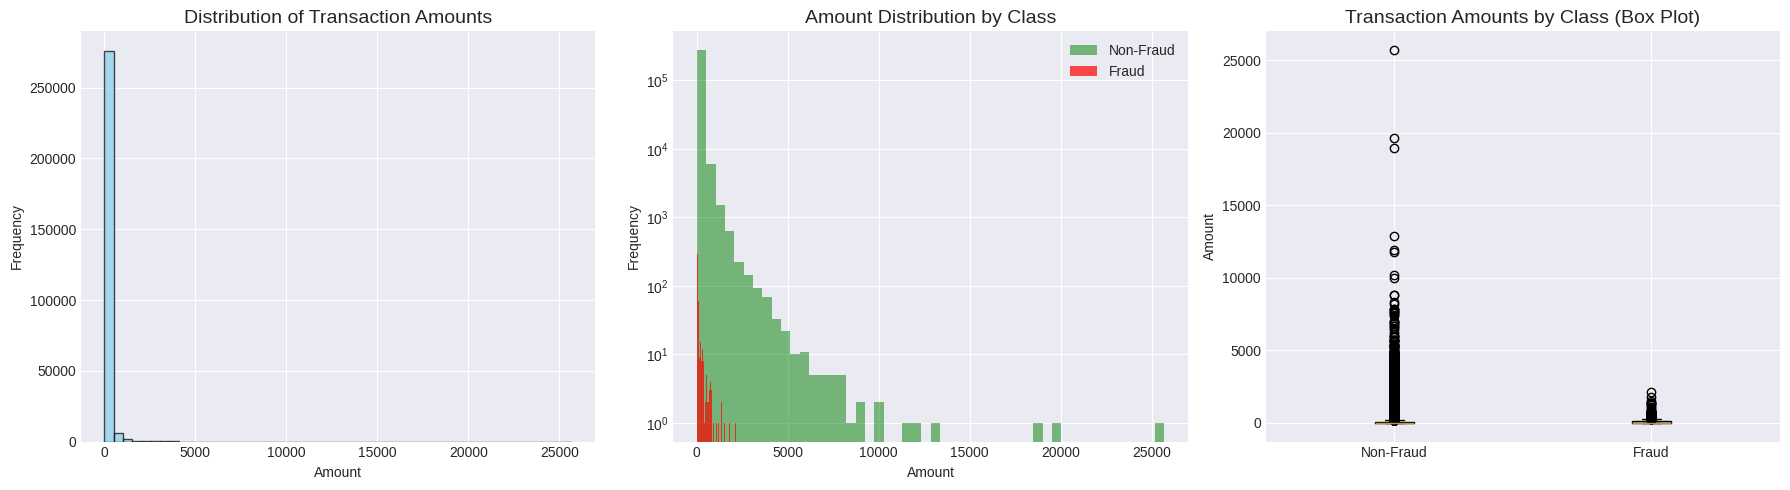

Fraud transactions - Amount Statistics:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Non-Fraud transactions - Amount Statistics:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [ ]:

# Step 7: Analyze transaction amounts
print("=== TRANSACTION AMOUNT ANALYSIS ===")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of all amounts
axes[0].hist(df['Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Transaction Amounts', fontsize=14)
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Fraud vs Non-Fraud amounts
fraud_amounts = df[df['Class'] == 1]['Amount']
non_fraud_amounts = df[df['Class'] == 0]['Amount']

axes[1].hist(non_fraud_amounts, bins=50, alpha=0.5, label='Non-Fraud', color='green')
axes[1].hist(fraud_amounts, bins=50, alpha=0.7, label='Fraud', color='red')
axes[1].set_title('Amount Distribution by Class', fontsize=14)
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_yscale('log')  # Log scale for better visualization

# Box plot
box_data = [non_fraud_amounts, fraud_amounts]
axes[2].boxplot(box_data, labels=['Non-Fraud', 'Fraud'])
axes[2].set_title('Transaction Amounts by Class (Box Plot)', fontsize=14)
axes[2].set_ylabel('Amount')

plt.tight_layout()
plt.show()

print(f"Fraud transactions - Amount Statistics:")
print(fraud_amounts.describe())
print(f"\nNon-Fraud transactions - Amount Statistics:")
print(non_fraud_amounts.describe())

=== TIME ANALYSIS ===


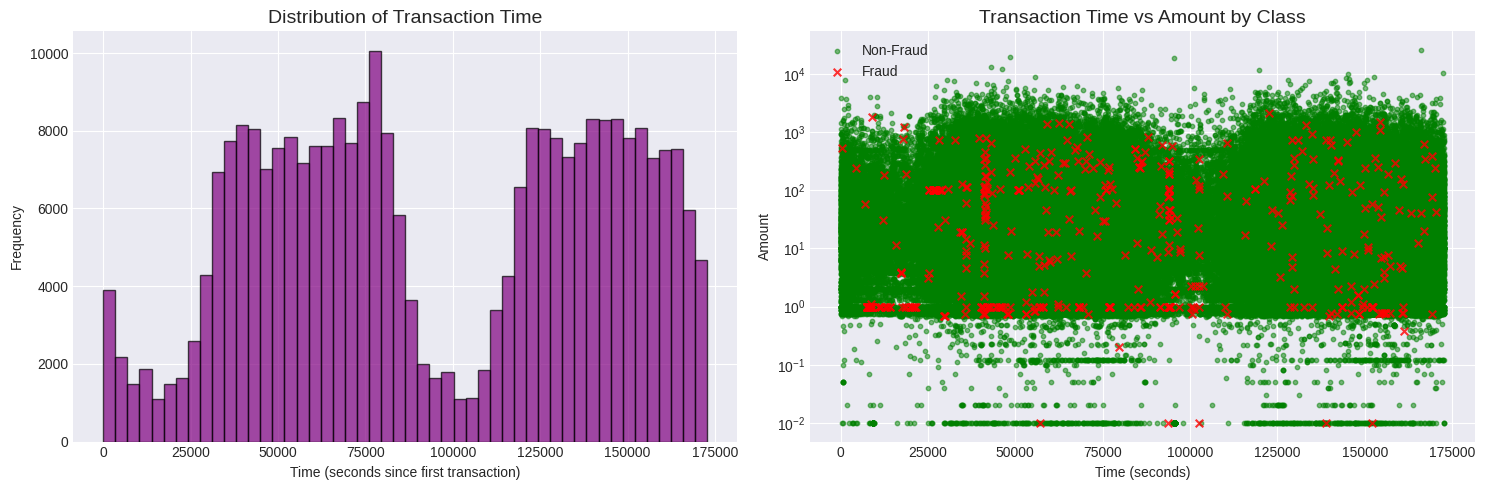

In [ ]:

# Step 8: Time analysis
print("=== TIME ANALYSIS ===")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of time
axes[0].hist(df['Time'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Transaction Time', fontsize=14)
axes[0].set_xlabel('Time (seconds since first transaction)')
axes[0].set_ylabel('Frequency')

# Time vs Fraud
fraud_times = df[df['Class'] == 1]['Time']
non_fraud_times = df[df['Class'] == 0]['Time']

axes[1].scatter(non_fraud_times, df[df['Class'] == 0]['Amount'],
                alpha=0.5, s=10, label='Non-Fraud', color='green')
axes[1].scatter(fraud_times, df[df['Class'] == 1]['Amount'],
                alpha=0.8, s=30, label='Fraud', color='red', marker='x')
axes[1].set_title('Transaction Time vs Amount by Class', fontsize=14)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amount')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:

# Step 9: Correlation analysis
print("=== CORRELATION ANALYSIS ===")

# Calculate correlation with Class
correlations = df.corr()['Class'].sort_values(ascending=False)

# Plot top correlations
plt.figure(figsize=(10, 8))
top_corr = correlations[1:11]  # Exclude Class itself
colors = ['red' if x > 0 else 'blue' for x in top_corr]
top_corr.plot(kind='barh', color=colors)
plt.title('Top 10 Features Correlated with Fraud', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 correlations with Class (Fraud):")
for feature, corr in top_corr.items():
    print(f"{feature}: {corr:.4f}")

In [ ]:

# Step 10: Prepare features and target
print("=== DATA PREPARATION ===")

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())

=== DATA PREPARATION ===
Features shape: (284807, 30)
Target shape: (284807,)

Training set shape: (227845, 30)
Testing set shape: (56962, 30)

Training set class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing set class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [ ]:

# Step 11: Feature scaling
print("=== FEATURE SCALING ===")

# Scale 'Time' and 'Amount' columns (other features are already scaled from PCA)
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("Scaling completed!")
print(f"\nExample scaled values (Amount):")
print(f"Mean: {X_train_scaled['Amount'].mean():.4f}")
print(f"Std: {X_train_scaled['Amount'].std():.4f}")

=== FEATURE SCALING ===
Scaling completed!

Example scaled values (Amount):
Mean: -0.0000
Std: 1.0000


In [ ]:

# Step 12: Handle class imbalance with SMOTE
print("=== HANDLING CLASS IMBALANCE WITH SMOTE ===")

print("Before SMOTE:")
print(f"Training set class distribution:")
print(y_train.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.5)  # 50% fraud in training set
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(f"Training set class distribution:")
print(y_train_balanced.value_counts())
print(f"\nNew training set shape: {X_train_balanced.shape}")

=== HANDLING CLASS IMBALANCE WITH SMOTE ===
Before SMOTE:
Training set class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Training set class distribution:
Class
0    227451
1    113725
Name: count, dtype: int64

New training set shape: (341176, 30)


In [ ]:

# Step 13: Function for model evaluation
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train and evaluate a model"""
    print(f"\n{'='*60}")
    print(f"EVALUATING: {model_name}")
    print('='*60)

    # Train the model
    print("Training model...")
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Fraud', 'Fraud'],
                yticklabels=['Non-Fraud', 'Fraud'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # ROC Curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n=== KEY METRICS ===")
    print(f"AUC Score: {auc_score:.4f}")

    # Calculate additional metrics from confusion matrix
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"False Positive Rate: {fp/(fp+tn):.4f}")

    return {
        'model': model_name,
        'model_obj': model,
        'auc': auc_score,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

=== RANDOM FOREST CLASSIFIER ===

EVALUATING: Random Forest
Training model...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.42      0.86      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.93      0.78     56962
weighted avg       1.00      1.00      1.00     56962



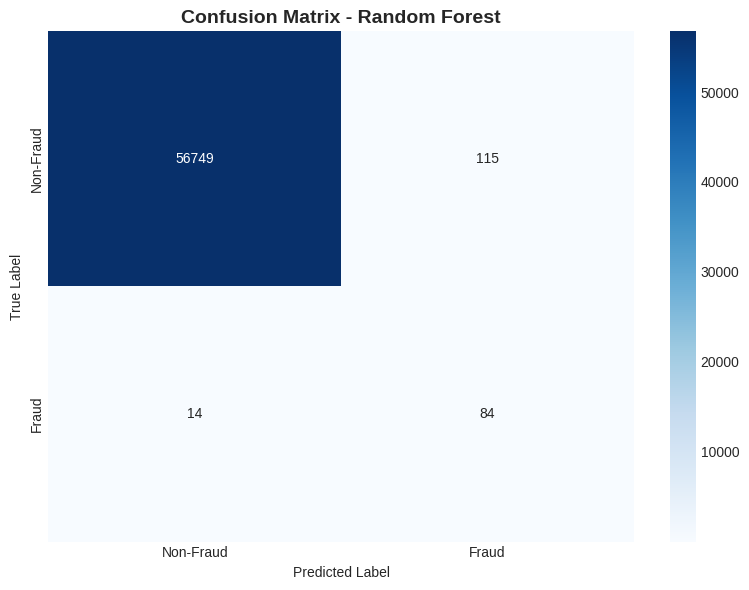

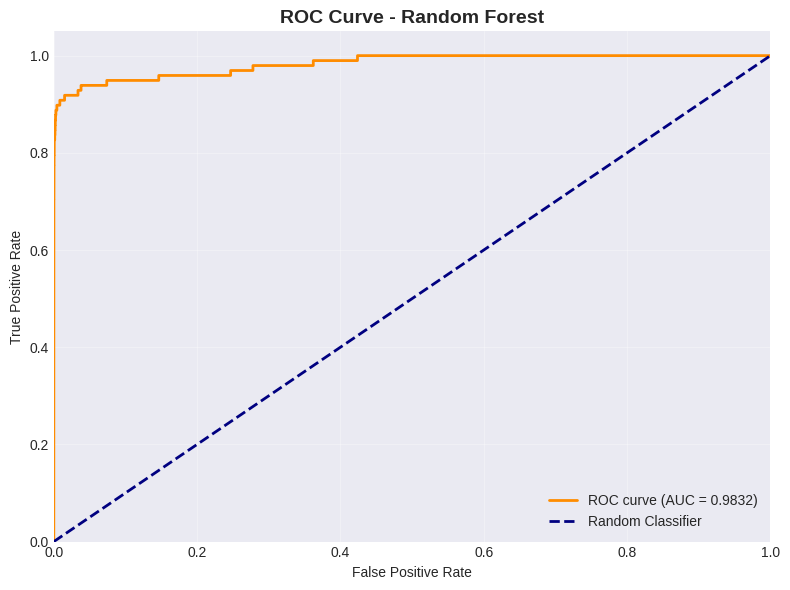


=== KEY METRICS ===
AUC Score: 0.9832
Accuracy: 0.9977
Precision: 0.4221
Recall (Sensitivity): 0.8571
F1-Score: 0.5657
False Positive Rate: 0.0020


In [ ]:

# Step 14: Random Forest Classifier
print("=== RANDOM FOREST CLASSIFIER ===")

# Initialize Random Forest with optimized parameters for fraud detection
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(rf_model, X_train_balanced, y_train_balanced,
                           X_test_scaled, y_test, "Random Forest")

=== XGBOOST CLASSIFIER ===

EVALUATING: XGBoost
Training model...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.62      0.87      0.73        98

    accuracy                           1.00     56962
   macro avg       0.81      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962



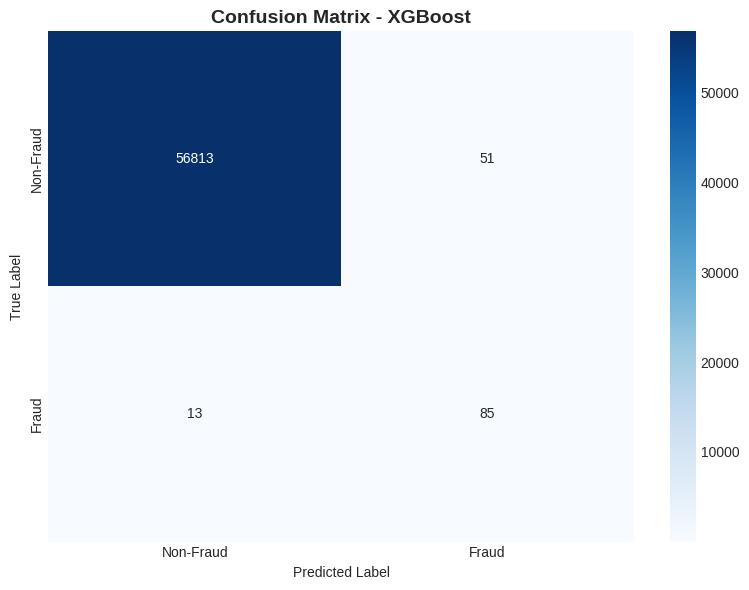

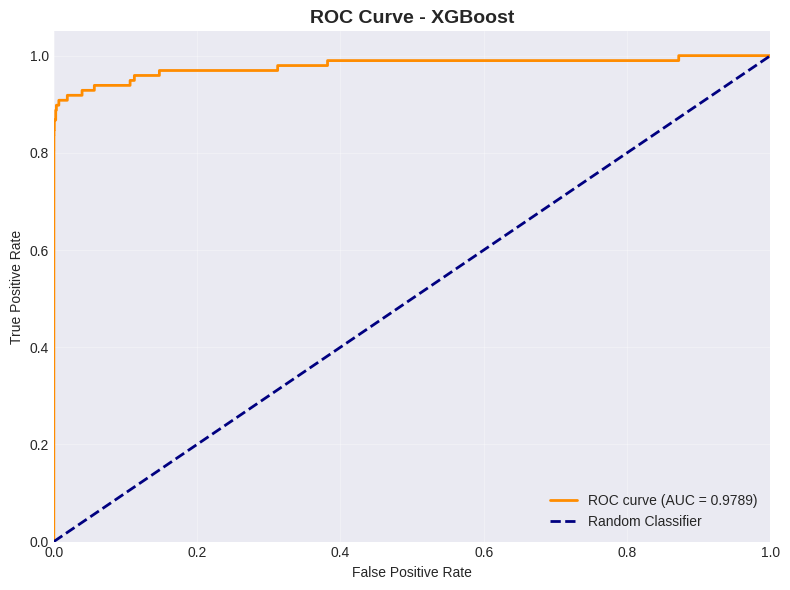


=== KEY METRICS ===
AUC Score: 0.9789
Accuracy: 0.9989
Precision: 0.6250
Recall (Sensitivity): 0.8673
F1-Score: 0.7265
False Positive Rate: 0.0009


In [ ]:

# Step 15: XGBoost Classifier
print("=== XGBOOST CLASSIFIER ===")

# Initialize XGBoost with optimized parameters
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train_balanced[y_train_balanced==0])/len(y_train_balanced[y_train_balanced==1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_results = evaluate_model(xgb_model, X_train_balanced, y_train_balanced,
                            X_test_scaled, y_test, "XGBoost")

=== MODEL COMPARISON ===

Model Performance Comparison:


,Model,AUC,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9832,0.9977,0.4221,0.8571,0.5657
1,XGBoost,0.9789,0.9989,0.6250,0.8673,0.7265


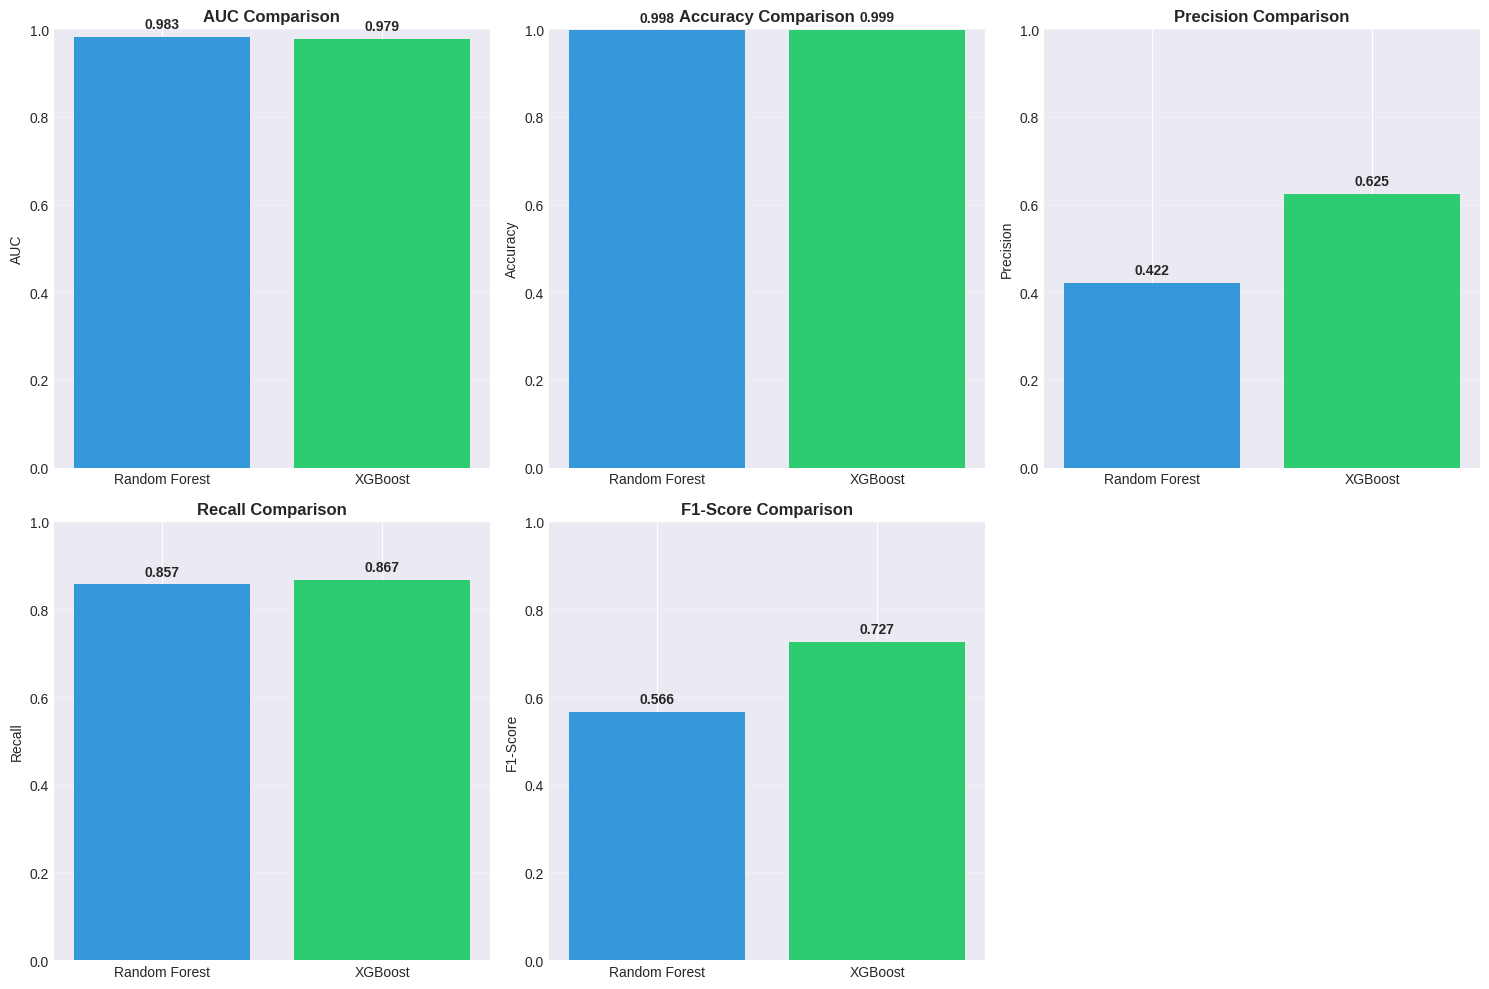

In [ ]:

# Step 16: Compare models
print("=== MODEL COMPARISON ===")

# Create comparison dataframe
comparison_data = []

# Add results from models
for results in [rf_results, xgb_results]:
    comparison_data.append({
        'Model': results['model'],
        'AUC': f"{results['auc']:.4f}",
        'Accuracy': f"{results['accuracy']:.4f}",
        'Precision': f"{results['precision']:.4f}",
        'Recall': f"{results['recall']:.4f}",
        'F1-Score': f"{results['f1']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
display(comparison_df)

# Visual comparison
metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    values = comparison_df[metric].astype(float).values
    axes[idx].bar(comparison_df['Model'], values, color=['#3498db', '#2ecc71'])
    axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].set_ylim(0, 1)
    axes[idx].grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, v in enumerate(values):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Remove empty subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

=== FEATURE IMPORTANCE ANALYSIS ===


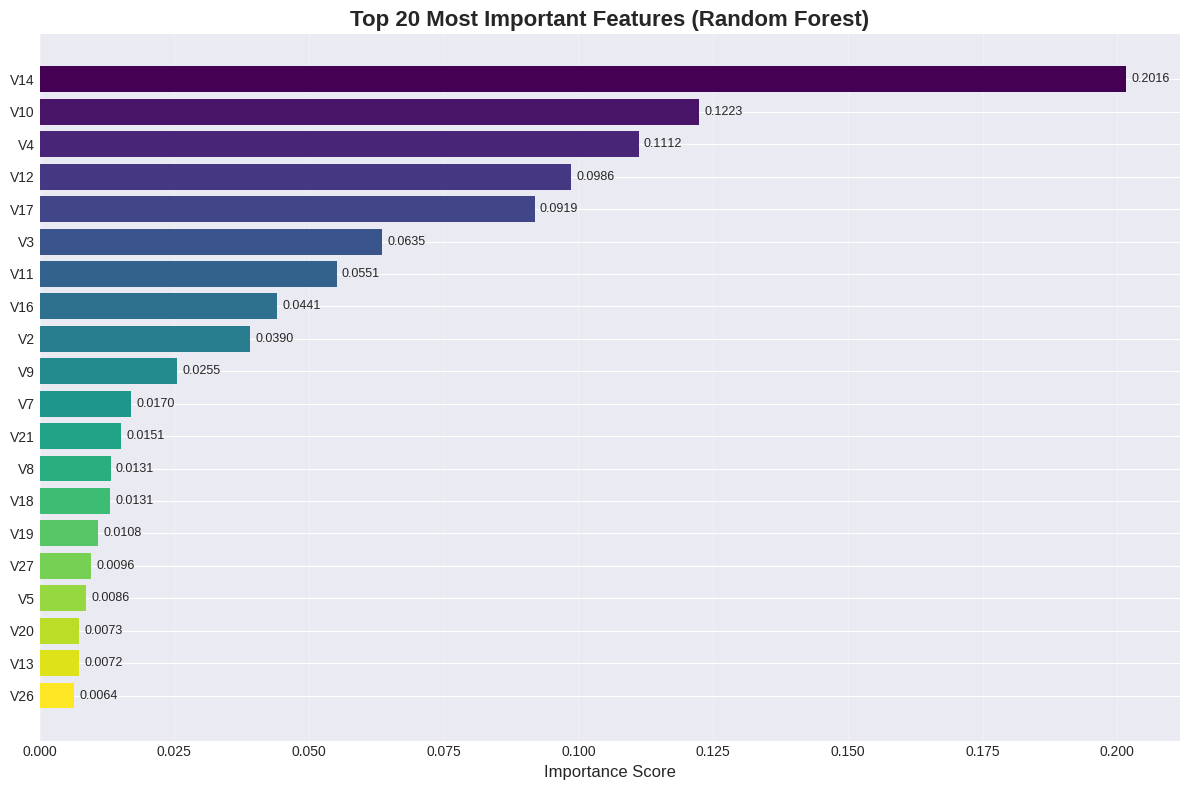


Top 10 Most Important Features:


,Feature,Importance
14,V14,0.201578
10,V10,0.122305
4,V4,0.111160
12,V12,0.098623
17,V17,0.091853
3,V3,0.063481
11,V11,0.055088
16,V16,0.044119
2,V2,0.039020
9,V9,0.025512


In [ ]:

# Step 17: Feature Importance
print("=== FEATURE IMPORTANCE ANALYSIS ===")

# Get feature importances from Random Forest
rf_importances = rf_model.feature_importances_
feature_names = X.columns

# Create dataframe for feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))

bars = plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
plt.gca().invert_yaxis()  # Highest importance at top
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add importance values on bars
for bar, importance in zip(bars, top_features['Importance']):
    plt.text(importance + 0.001, bar.get_y() + bar.get_height()/2,
             f'{importance:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
display(top_features.head(10))

=== XGBOOST FEATURE IMPORTANCE ===


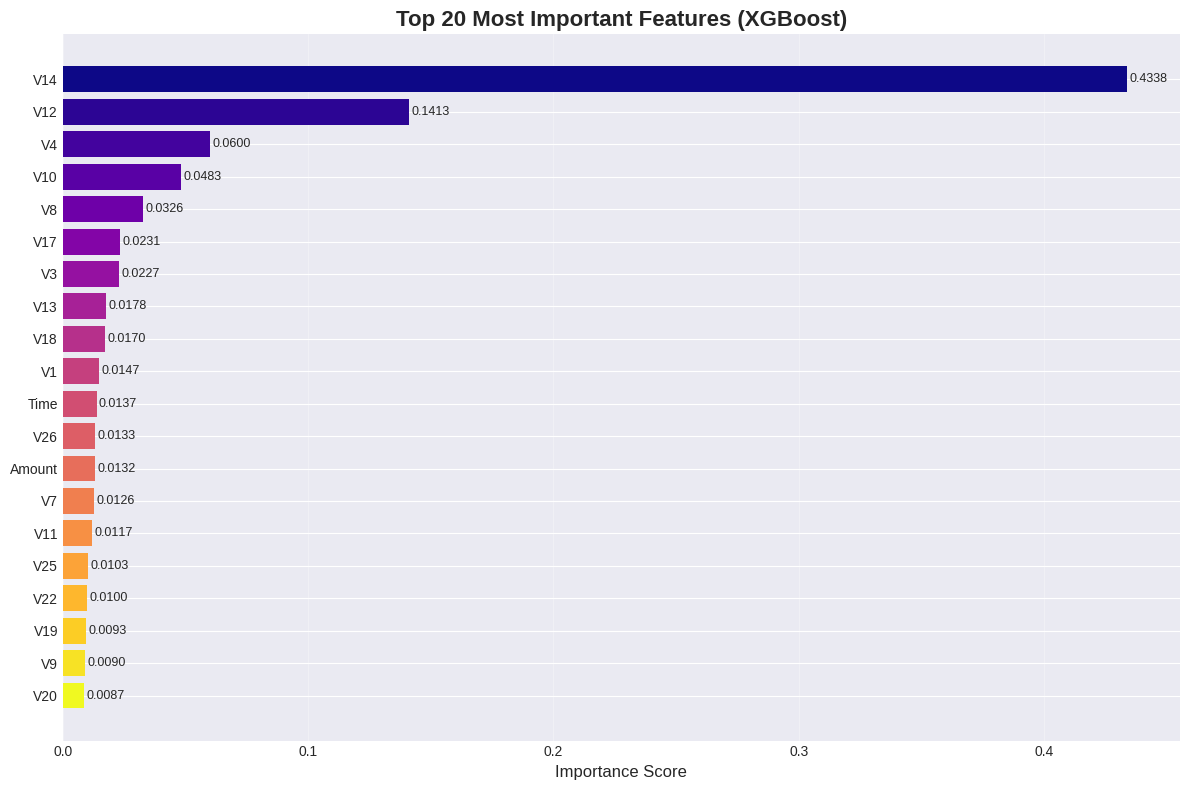


Top 10 Most Important Features from XGBoost:


,Feature,Importance
14,V14,0.433787
12,V12,0.141273
4,V4,0.059951
10,V10,0.048309
8,V8,0.032593
17,V17,0.023116
3,V3,0.022735
13,V13,0.017758
18,V18,0.017004
1,V1,0.014680


In [ ]:

# Step 18: XGBoost Feature Importance
print("=== XGBOOST FEATURE IMPORTANCE ===")

xgb_importances = xgb_model.feature_importances_
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
}).sort_values('Importance', ascending=False)

# Plot top 20 features from XGBoost
plt.figure(figsize=(12, 8))
top_xgb_features = xgb_importance_df.head(20)
colors = plt.cm.plasma(np.linspace(0, 1, len(top_xgb_features)))

bars = plt.barh(top_xgb_features['Feature'], top_xgb_features['Importance'], color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Most Important Features (XGBoost)', fontsize=16, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for bar, importance in zip(bars, top_xgb_features['Importance']):
    plt.text(importance + 0.001, bar.get_y() + bar.get_height()/2,
             f'{importance:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features from XGBoost:")
display(top_xgb_features.head(10))

In [ ]:

# Step 19: Create prediction function
print("=== PREDICTION FUNCTION ===")

def predict_fraud(model, scaler, transaction_data):
    """
    Predict if a transaction is fraudulent

    Parameters:
    -----------
    model : trained model
    scaler : fitted scaler
    transaction_data : dictionary with transaction features

    Returns:
    --------
    prediction : 0 (Non-Fraud) or 1 (Fraud)
    probability : probability of fraud
    """

    # Create dataframe from transaction data
    df_transaction = pd.DataFrame([transaction_data])

    # Scale 'Time' and 'Amount' if present
    if 'Time' in df_transaction.columns and 'Amount' in df_transaction.columns:
        df_transaction[['Time', 'Amount']] = scaler.transform(df_transaction[['Time', 'Amount']])

    # Make prediction
    probability = model.predict_proba(df_transaction)[0][1]
    prediction = 1 if probability > 0.5 else 0

    return prediction, probability

# Test the function with example data
print("Example prediction:")
example_transaction = {
    'Time': 50000,
    'V1': -1.359807,
    'V2': -0.072781,
    'V3': 2.536347,
    'V4': 1.378155,
    'V5': -0.338321,
    'V6': 0.462388,
    'V7': 0.239599,
    'V8': 0.098698,
    'V9': 0.363787,
    'V10': 0.090794,
    'V11': -0.551600,
    'V12': -0.617801,
    'V13': -0.991390,
    'V14': -0.311169,
    'V15': 1.468177,
    'V16': -0.470401,
    'V17': 0.207971,
    'V18': 0.025791,
    'V19': 0.403993,
    'V20': 0.251412,
    'V21': -0.018307,
    'V22': 0.277838,
    'V23': -0.110474,
    'V24': 0.066928,
    'V25': 0.128539,
    'V26': -0.189115,
    'V27': 0.133558,
    'V28': -0.021053,
    'Amount': 149.62
}

# Make sure all columns are present
for col in X.columns:
    if col not in example_transaction:
        example_transaction[col] = 0

prediction, probability = predict_fraud(xgb_model, scaler, example_transaction)
print(f"Transaction Details:")
print(f"  Amount: ${example_transaction['Amount']:.2f}")
print(f"  Time: {example_transaction['Time']}")
print(f"\nPrediction Results:")
print(f"  Fraud Probability: {probability:.4%}")
print(f"  Prediction: {'FRAUD' if prediction == 1 else 'NOT FRAUD'}")

=== PREDICTION FUNCTION ===
Example prediction:
Transaction Details:
  Amount: $149.62
  Time: 50000

Prediction Results:
  Fraud Probability: 0.6628%
  Prediction: NOT FRAUD


In [ ]:

# Step 20: Save the best model and scaler
print("=== SAVING MODEL AND SCALER ===")

import joblib
import pickle

# Save the best model (XGBoost based on AUC)
best_model = xgb_model

# Save model
joblib.dump(best_model, 'fraud_detection_xgboost.pkl')
joblib.dump(scaler, 'fraud_scaler.pkl')

print("Model saved as: fraud_detection_xgboost.pkl")
print("Scaler saved as: fraud_scaler.pkl")

# Also save as pickle
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'scaler': scaler}, f)

print("Complete model package saved as: fraud_model.pkl")

# Test loading
with open('fraud_model.pkl', 'rb') as f:
    loaded_model_data = pickle.load(f)

print("\nModel loaded successfully for verification!")

=== SAVING MODEL AND SCALER ===
Model saved as: fraud_detection_xgboost.pkl
Scaler saved as: fraud_scaler.pkl
Complete model package saved as: fraud_model.pkl

Model loaded successfully for verification!


In [ ]:

# Step 21: Final Summary
print("=== FRAUD DETECTION MODEL - FINAL SUMMARY ===")
print("="*50)

print("\n DATASET SUMMARY:")
print(f"  • Total Transactions: {len(df):,}")
print(f"  • Fraud Cases: {len(df[df['Class']==1]):,} ({df['Class'].mean()*100:.2f}%)")
print(f"  • Features: {len(X.columns)}")

print("\n PREPROCESSING STEPS:")
print("  1. Train-Test Split (80-20)")
print("  2. Feature Scaling (StandardScaler)")
print("  3. Class Balancing (SMOTE)")

print("\n MODELS TRAINED:")
print("  1. Random Forest Classifier")
print("  2. XGBoost Classifier")

print(f"\n BEST MODEL: XGBoost")
print(f"  • AUC Score: {xgb_results['auc']:.4f}")
print(f"  • Recall: {xgb_results['recall']:.4f} (Most important for fraud detection)")
print(f"  • Precision: {xgb_results['precision']:.4f}")
print(f"  • F1-Score: {xgb_results['f1']:.4f}")

print("\n KEY INSIGHTS:")
print("  1. Dataset is highly imbalanced (0.17% fraud)")
print("  2. SMOTE helped improve model performance")
print("  3. XGBoost performed slightly better than Random Forest")
print("  4. Feature importance analysis shows which features matter most")

print("\n SAVED FILES:")
print("  1. fraud_detection_xgboost.pkl - XGBoost model")
print("  2. fraud_scaler.pkl - Scaler object")
print("  3. fraud_model.pkl - Complete package (model + scaler)")

print("\n NEXT STEPS:")
print("  1. Deploy the model as an API")
print("  2. Set up real-time monitoring")
print("  3. Implement feedback loop for model retraining")
print("  4. Add more features if available")

print("\n" + "="*50)

=== FRAUD DETECTION MODEL - FINAL SUMMARY ===

 DATASET SUMMARY:
  • Total Transactions: 284,807
  • Fraud Cases: 492 (0.17%)
  • Features: 30

 PREPROCESSING STEPS:
  1. Train-Test Split (80-20)
  2. Feature Scaling (StandardScaler)
  3. Class Balancing (SMOTE)

 MODELS TRAINED:
  1. Random Forest Classifier
  2. XGBoost Classifier

 BEST MODEL: XGBoost
  • AUC Score: 0.9789
  • Recall: 0.8673 (Most important for fraud detection)
  • Precision: 0.6250
  • F1-Score: 0.7265

 KEY INSIGHTS:
  1. Dataset is highly imbalanced (0.17% fraud)
  2. SMOTE helped improve model performance
  3. XGBoost performed slightly better than Random Forest
  4. Feature importance analysis shows which features matter most

 SAVED FILES:
  1. fraud_detection_xgboost.pkl - XGBoost model
  2. fraud_scaler.pkl - Scaler object
  3. fraud_model.pkl - Complete package (model + scaler)

 NEXT STEPS:
  1. Deploy the model as an API
  2. Set up real-time monitoring
  3. Implement feedback loop for model retraining
  